## Libraries and Data

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib


In [2]:
# Set File Paths

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(exist_ok=True)

In [3]:
# Load Dataset

energy_df = pd.read_csv(DATA_DIR / "processed" / "energy_household_with_target_step3.csv")

print("Dataset loaded successfully!")
print("Shape:", energy_df.shape)

energy_df.head()

Dataset loaded successfully!
Shape: (3599, 56)


,hhid,zone,state,lga,urca_cat,adult_count,members_under_18,members_18_30,members_31_55,members_over_55,...,fridge_monthly_kwh,ac_monthly_kwh,washing_machine_monthly_kwh,electric_cooker_monthly_kwh,thermal_appliance_monthly_kwh,air_cooler_monthly_kwh,estimated_monthly_kwh,supply_factor,estimated_monthly_kwh_adjusted,consumption_category
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,North Central,Niger,mashegu,<1hr to small city/town+,5,13,4,1,0,...,54.0,0.0,0.0,0.0,18.0,0.0,39.300,0.200000,39.300,High Consumption
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,North Central,Niger,mashegu,<1hr to small city/town+,6,4,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,12.375,0.250000,12.375,Moderate Consumption
2,435c8e27-517a-46b9-af04-48830e086d7a,North West,Kano,garun_malam,<1hr to large city,3,3,2,1,0,...,0.0,0.0,0.0,0.0,18.0,0.0,51.225,0.500000,51.225,Very High Consumption
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,North West,Kano,garun_malam,<1hr to large city,3,7,2,1,0,...,54.0,0.0,0.0,0.0,18.0,12.0,157.200,0.500000,157.200,Very High Consumption
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,North West,Kano,garun_malam,<1hr to large city,2,4,1,1,0,...,0.0,0.0,0.0,0.0,18.0,0.0,4.875,0.208333,4.875,Moderate Consumption


##### Create Clustering Features

In [4]:
# Create Clustering Features

# Create average AC usage hours feature
energy_df['average_ac_usage_hours'] = np.where(
    energy_df['ac_count'] > 0,
    4,
    0
)

clustering_features = [
    'household_size',
    'number_of_rooms',
    'daily_supply_hours',
    'light_bulb_count',
    'fan_count',
    'television_count',
    'fridge_count',
    'ac_count',
    'average_ac_usage_hours',
    'estimated_monthly_kwh'
]

# Keep only columns that exist
clustering_features = [
    col for col in clustering_features
    if col in energy_df.columns
]

cluster_df = energy_df[clustering_features].copy()

cluster_df.head()

,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
0,18,8,4.0,15,8,2,1,0,0,39.300
1,10,9,6.0,12,1,1,0,0,0,12.375
2,6,5,12.0,6,2,1,0,0,0,51.225
3,10,10,12.0,20,6,1,1,0,0,157.200
4,6,3,5.0,3,0,0,0,0,0,4.875


In [5]:
# Clean Clustering Dataset

for col in clustering_features:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors='coerce')

cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)

cluster_df = cluster_df.dropna()

print("Clean clustering dataset shape:", cluster_df.shape)

cluster_df.head()

Clean clustering dataset shape: (3599, 10)


,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
0,18,8,4.0,15,8,2,1,0,0,39.300
1,10,9,6.0,12,1,1,0,0,0,12.375
2,6,5,12.0,6,2,1,0,0,0,51.225
3,10,10,12.0,20,6,1,1,0,0,157.200
4,6,3,5.0,3,0,0,0,0,0,4.875


##### Scale the Features

In [6]:
# Scale Features

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_df)

cluster_scaled[:5]

array([[ 2.1716655 ,  1.04986425, -0.52750445,  1.90059444,  3.16601918,
         1.30466137,  1.14715248, -0.24766679, -0.24766679, -0.0095816 ],
       [ 0.58682802,  1.37641005, -0.18354421,  1.20800548, -0.45884544,
         0.20010332, -0.8717237 , -0.24766679, -0.24766679, -0.47040515],
       [-0.20559072,  0.07022685,  0.84833649, -0.17717243,  0.05899236,
         0.20010332, -0.8717237 , -0.24766679, -0.24766679,  0.19451574],
       [ 0.58682802,  1.70295585,  0.84833649,  3.05490936,  2.13034357,
         0.20010332,  1.14715248, -0.24766679, -0.24766679,  2.00828645],
       [-0.20559072, -0.58286475, -0.35552433, -0.86976138, -0.97668325,
        -0.90445473, -0.8717237 , -0.24766679, -0.24766679, -0.59876826]])

##### Find Best Number of Clusters with Elbow Method

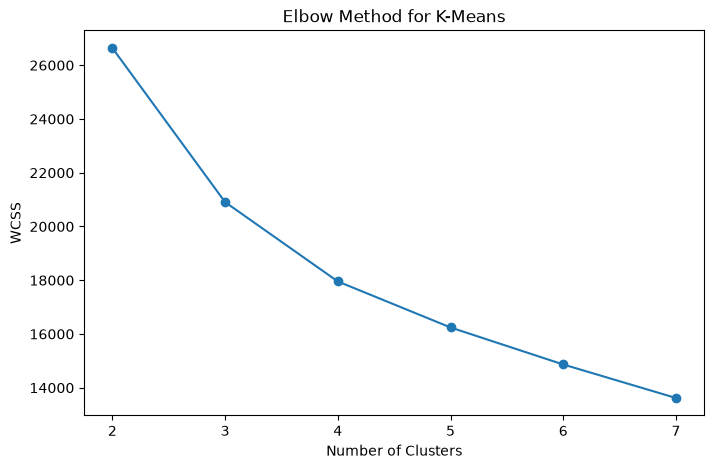

In [7]:
# Elbow Method for K-Means

wcss = []

k_values = range(2, 8)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(cluster_scaled)
    
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(k_values, wcss, marker='o')

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

##### Check K-Means Silhouette Scores

In [8]:
# K-Means Silhouette Scores

kmeans_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(cluster_scaled)
    
    score = silhouette_score(cluster_scaled, labels)
    
    kmeans_scores.append(score)

kmeans_score_df = pd.DataFrame({
    'Number of Clusters': list(k_values),
    'Silhouette Score': kmeans_scores
})

kmeans_score_df

,Number of Clusters,Silhouette Score
0,2,0.582027
1,3,0.288910
2,4,0.285400
3,5,0.247485
4,6,0.252458
5,7,0.257372


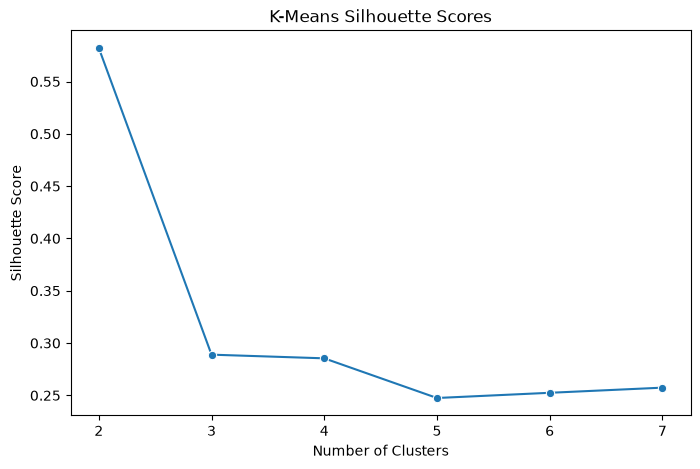

In [9]:
# K-Means Silhouette Score Plot

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=kmeans_score_df,
    x='Number of Clusters',
    y='Silhouette Score',
    marker='o'
)

plt.title("K-Means Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [10]:
# Train Final K-Means Model

best_kmeans_k = kmeans_score_df.sort_values(
    by='Silhouette Score',
    ascending=False
).iloc[0]['Number of Clusters']

best_kmeans_k = int(best_kmeans_k)

print("Best number of clusters for K-Means:", best_kmeans_k)

final_kmeans = KMeans(
    n_clusters=best_kmeans_k,
    random_state=42,
    n_init=10
)

energy_df['kmeans_cluster'] = final_kmeans.fit_predict(cluster_scaled)

energy_df['kmeans_cluster'].value_counts()

Best number of clusters for K-Means: 2


kmeans_cluster
1    3372
0     227
Name: count, dtype: int64

##### Train Hierarchical Clustering Models

In [11]:
# Hierarchical Clustering Silhouette Scores

hierarchical_scores = []

for k in k_values:
    hierarchical = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    
    labels = hierarchical.fit_predict(cluster_scaled)
    
    score = silhouette_score(cluster_scaled, labels)
    
    hierarchical_scores.append(score)

hierarchical_score_df = pd.DataFrame({
    'Number of Clusters': list(k_values),
    'Silhouette Score': hierarchical_scores
})

hierarchical_score_df

,Number of Clusters,Silhouette Score
0,2,0.564055
1,3,0.285889
2,4,0.266237
3,5,0.217876
4,6,0.218296
5,7,0.183334


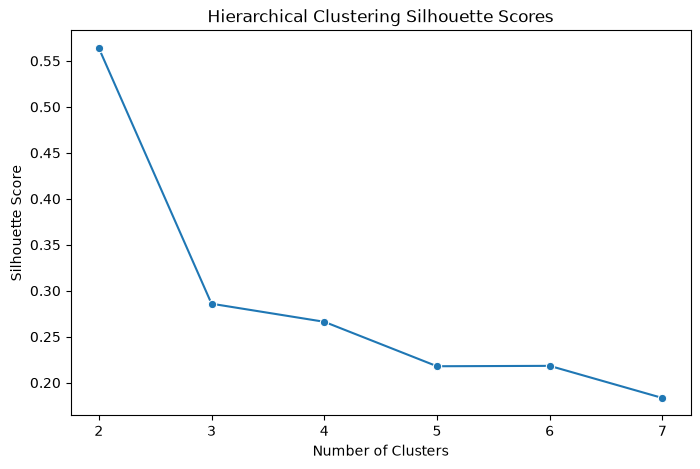

In [12]:
# Hierarchical Silhouette Score Plot

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=hierarchical_score_df,
    x='Number of Clusters',
    y='Silhouette Score',
    marker='o'
)

plt.title("Hierarchical Clustering Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [13]:
# Train Final Hierarchical Model

best_hierarchical_k = hierarchical_score_df.sort_values(
    by='Silhouette Score',
    ascending=False
).iloc[0]['Number of Clusters']

best_hierarchical_k = int(best_hierarchical_k)

print("Best number of clusters for Hierarchical Clustering:", best_hierarchical_k)

final_hierarchical = AgglomerativeClustering(
    n_clusters=best_hierarchical_k,
    linkage='ward'
)

energy_df['hierarchical_cluster'] = final_hierarchical.fit_predict(cluster_scaled)

energy_df['hierarchical_cluster'].value_counts()

Best number of clusters for Hierarchical Clustering: 2


hierarchical_cluster
0    3392
1     207
Name: count, dtype: int64

In [14]:
# Compare Clustering Models

best_kmeans_score = kmeans_score_df['Silhouette Score'].max()
best_hierarchical_score = hierarchical_score_df['Silhouette Score'].max()

clustering_comparison = pd.DataFrame({
    'Model': ['K-Means Clustering', 'Hierarchical Clustering'],
    'Best Number of Clusters': [best_kmeans_k, best_hierarchical_k],
    'Best Silhouette Score': [best_kmeans_score, best_hierarchical_score]
})

clustering_comparison

,Model,Best Number of Clusters,Best Silhouette Score
0,K-Means Clustering,2,0.582027
1,Hierarchical Clustering,2,0.564055


##### Select Main Clustering Model for App

In [15]:
# Select Main Clustering Model for App

main_clustering_model = final_kmeans

print("Main clustering model for the app: K-Means")
print("Reason: K-Means can assign new user inputs to a cluster.")

Main clustering model for the app: K-Means
Reason: K-Means can assign new user inputs to a cluster.


In [16]:
# Create K-Means Cluster Profile

kmeans_cluster_profile = energy_df.groupby('kmeans_cluster')[clustering_features].mean()

kmeans_cluster_profile

,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
kmeans_cluster,,,,,,,,,,
0,6.960352,6.162996,12.273128,10.863436,4.017621,1.964758,0.960352,0.9163,3.665198,178.851217
1,7.043001,4.692171,6.716785,6.491696,1.742586,0.741696,0.396204,0.0000,0.000000,30.503059


In [17]:
# Hierarchical Cluster Profile

hierarchical_cluster_profile = energy_df.groupby('hierarchical_cluster')[clustering_features].mean()

hierarchical_cluster_profile

,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
hierarchical_cluster,,,,,,,,,,
0,7.146226,4.755012,6.759139,6.582252,1.799233,0.768868,0.399469,0.000295,0.001179,31.889294
1,5.260870,5.275362,12.115942,9.801932,3.309179,1.637681,0.961353,1.000000,4.000000,170.468877


##### Name the Household Energy Segments

In [18]:
# Name Household Energy Segments

overall_kwh_median = energy_df['estimated_monthly_kwh'].median()
overall_kwh_75 = energy_df['estimated_monthly_kwh'].quantile(0.75)

overall_ac_median = energy_df['ac_count'].median()
overall_fan_median = energy_df['fan_count'].median()
overall_fridge_median = energy_df['fridge_count'].median()


def name_energy_segment(row):
    if row['estimated_monthly_kwh'] >= overall_kwh_75:
        if row['ac_count'] > overall_ac_median:
            return "Cooling-Heavy High Consumption"
        elif row['fridge_count'] > overall_fridge_median:
            return "Appliance-Heavy High Consumption"
        else:
            return "High Consumption Household"

    elif row['estimated_monthly_kwh'] >= overall_kwh_median:
        if row['fan_count'] > overall_fan_median:
            return "Moderate Fan-Heavy Household"
        else:
            return "Moderate Consumption Household"

    else:
        return "Low-Use Basic Household"


energy_df['energy_segment'] = energy_df.apply(name_energy_segment, axis=1)

energy_df['energy_segment'].value_counts()

energy_segment
Low-Use Basic Household             1799
Appliance-Heavy High Consumption     610
Moderate Consumption Household       492
Moderate Fan-Heavy Household         408
Cooling-Heavy High Consumption       200
High Consumption Household            90
Name: count, dtype: int64

In [19]:
# Segment Profile

segment_profile = energy_df.groupby('energy_segment')[clustering_features].mean()

segment_profile

,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
energy_segment,,,,,,,,,,
Appliance-Heavy High Consumption,7.083607,5.168852,12.680328,9.052459,3.288525,1.455738,1.000000,0.000000,0.000000,99.573121
Cooling-Heavy High Consumption,5.440000,5.485000,12.415000,10.040000,3.470000,1.680000,0.965000,1.000000,4.000000,175.174994
High Consumption Household,8.344444,5.788889,17.322222,8.455556,2.911111,1.188889,0.000000,0.000000,0.000000,83.959806
Low-Use Basic Household,7.469705,4.626459,4.171762,5.229016,0.882713,0.362979,0.083380,0.000000,0.000000,6.495139
Moderate Consumption Household,5.654472,4.197154,8.333333,5.912602,1.388211,0.892276,0.615854,0.010163,0.040650,30.404408
Moderate Fan-Heavy Household,7.227941,5.053922,5.031863,9.188725,3.811275,1.284314,0.730392,0.007353,0.029412,33.041256


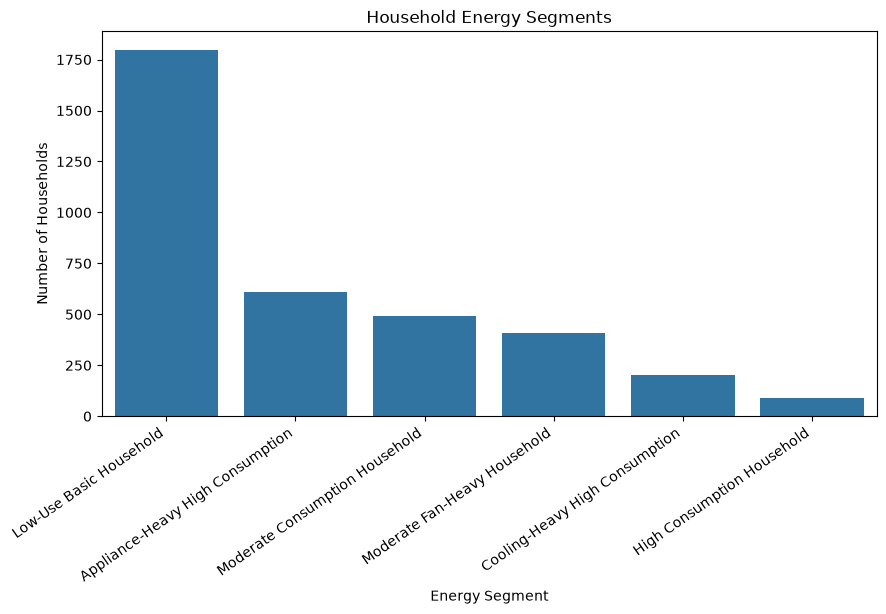

In [20]:
# Energy Segment Count Plot

plt.figure(figsize=(10, 5))

sns.countplot(
    data=energy_df,
    x='energy_segment',
    order=energy_df['energy_segment'].value_counts().index
)

plt.title("Household Energy Segments")
plt.xlabel("Energy Segment")
plt.ylabel("Number of Households")

plt.xticks(rotation=35, ha='right')

plt.show()

##### Reduce Clusters to 2D for Visualization

In [21]:
# Prepare 2D Cluster Visualization

pca = PCA(n_components=2)

cluster_2d = pca.fit_transform(cluster_scaled)

energy_df['pca_1'] = cluster_2d[:, 0]
energy_df['pca_2'] = cluster_2d[:, 1]

energy_df[['pca_1', 'pca_2', 'kmeans_cluster', 'energy_segment']].head()

,pca_1,pca_2,kmeans_cluster,energy_segment
0,2.595801,3.470226,1,Moderate Fan-Heavy Household
1,-0.172048,1.651435,1,Low-Use Basic Household
2,-0.117451,-0.030571,1,High Consumption Household
3,3.432582,2.378012,1,Appliance-Heavy High Consumption
4,-1.875530,-0.698028,1,Low-Use Basic Household


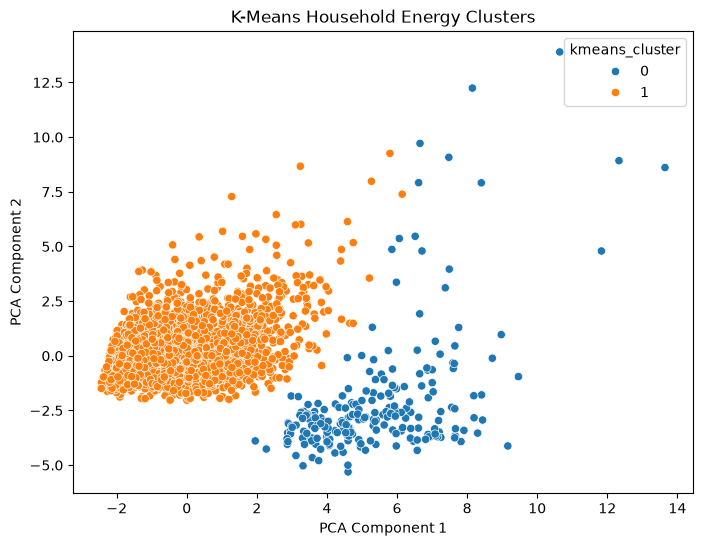

In [22]:
# K-Means Cluster Visualization

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=energy_df,
    x='pca_1',
    y='pca_2',
    hue='kmeans_cluster',
    palette='tab10'
)

plt.title("K-Means Household Energy Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

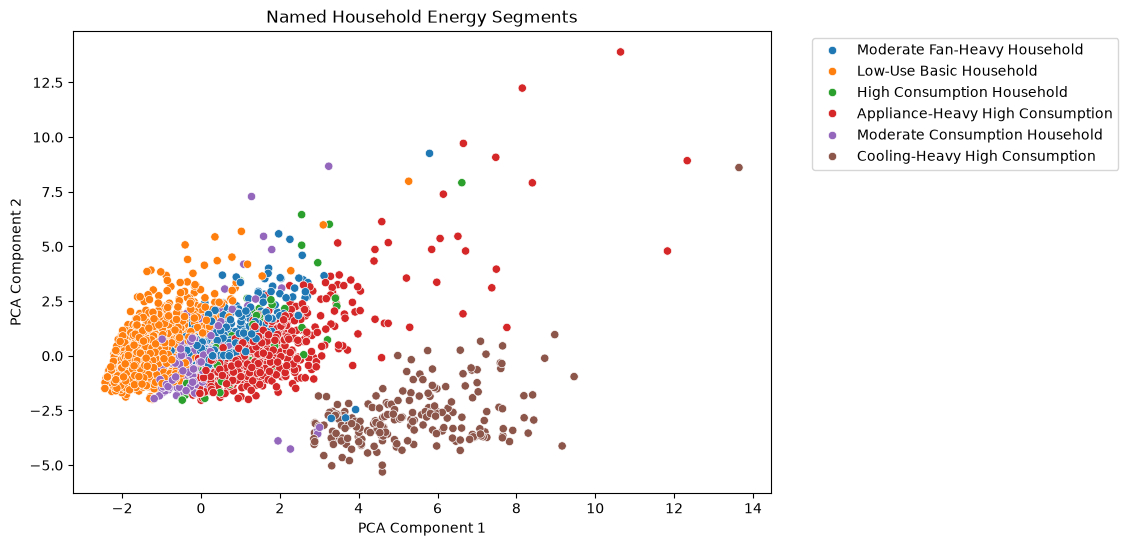

In [23]:
# Named Energy Segment Visualization

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=energy_df,
    x='pca_1',
    y='pca_2',
    hue='energy_segment'
)

plt.title("Named Household Energy Segments")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [24]:
# Preview Final Segmentation Result

preview_columns = [
    'hhid',
    'household_size',
    'number_of_rooms',
    'daily_supply_hours',
    'light_bulb_count',
    'fan_count',
    'television_count',
    'fridge_count',
    'ac_count',
    'estimated_monthly_kwh',
    'kmeans_cluster',
    'hierarchical_cluster',
    'energy_segment'
]

preview_columns = [
    col for col in preview_columns
    if col in energy_df.columns
]

energy_df[preview_columns].head(10)

,hhid,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,estimated_monthly_kwh,kmeans_cluster,hierarchical_cluster,energy_segment
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,18,8,4.0,15,8,2,1,0,39.30000,1,0,Moderate Fan-Heavy Household
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,10,9,6.0,12,1,1,0,0,12.37500,1,0,Low-Use Basic Household
2,435c8e27-517a-46b9-af04-48830e086d7a,6,5,12.0,6,2,1,0,0,51.22500,1,0,High Consumption Household
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,10,10,12.0,20,6,1,1,0,157.20000,1,0,Appliance-Heavy High Consumption
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,6,3,5.0,3,0,0,0,0,4.87500,1,0,Low-Use Basic Household
5,d3cb220c-85a6-4f47-b6f3-16afac111a0c,4,5,4.0,5,1,1,1,0,15.60000,1,0,Low-Use Basic Household
6,2778d899-69d6-4943-896f-de0175716609,9,10,6.0,10,0,0,0,0,4.80000,1,0,Low-Use Basic Household
7,6acc2fae-6517-4360-a48a-0b73aa89953c,21,9,8.0,8,0,0,0,0,6.20000,1,0,Low-Use Basic Household
8,2fb2310c-02b8-4c8c-97de-024b05008625,14,8,5.0,10,0,2,0,0,9.65625,1,0,Low-Use Basic Household
9,80a0c152-d59a-497e-9ae6-ecd97e4ce53f,8,5,6.0,5,0,0,0,0,7.38750,1,0,Low-Use Basic Household


##### Test Segment Assignment for a Sample Household

In [25]:
# This is similar to what the app will later do.

# The app will first predict monthly kWh using the supervised model, then use that predicted kWh to assign the household to a cluster.

# Test Sample Household Segment Assignment

sample_cluster_input = pd.DataFrame({
    'household_size': [4],
    'number_of_rooms': [3],
    'daily_supply_hours': [20],
    'light_bulb_count': [8],
    'fan_count': [3],
    'television_count': [1],
    'fridge_count': [1],
    'ac_count': [1],
    'average_ac_usage_hours': [4],
    'estimated_monthly_kwh': [250]
})

sample_cluster_input = sample_cluster_input[clustering_features]

sample_cluster_scaled = scaler.transform(sample_cluster_input)

sample_cluster = final_kmeans.predict(sample_cluster_scaled)[0]

print("Sample Household Cluster:", sample_cluster)

Sample Household Cluster: 0


##### Create Cluster-to-Segment Mapping

In [26]:
# Create Cluster-to-Segment Mapping

cluster_segment_mapping = {}

for cluster in sorted(energy_df['kmeans_cluster'].unique()):
    most_common_segment = energy_df[
        energy_df['kmeans_cluster'] == cluster
    ]['energy_segment'].mode()[0]
    
    cluster_segment_mapping[cluster] = most_common_segment

cluster_segment_mapping

{np.int32(0): 'Cooling-Heavy High Consumption',
 np.int32(1): 'Low-Use Basic Household'}

In [27]:
# Test Sample Household Segment Name

sample_segment_name = cluster_segment_mapping[sample_cluster]

print("Sample Household Segment:", sample_segment_name)

Sample Household Segment: Cooling-Heavy High Consumption


##### Save Clustering Outputs

In [28]:
# Save Clustering Outputs

# Save K-Means model
joblib.dump(final_kmeans, MODEL_DIR / "energy_kmeans_model.pkl")

# Save clustering scaler
joblib.dump(scaler, MODEL_DIR / "energy_cluster_scaler.pkl")

# Save clustering feature columns
joblib.dump(clustering_features, MODEL_DIR / "energy_clustering_features.pkl")

# Save cluster to segment mapping
joblib.dump(cluster_segment_mapping, MODEL_DIR / "cluster_segment_mapping.pkl")

# Save PCA model for visualization if needed
joblib.dump(pca, MODEL_DIR / "energy_cluster_pca.pkl")

# Save clustering comparison
clustering_comparison.to_csv(
    DATA_DIR / "processed" / "clustering_model_comparison.csv",
    index=False
)

# Save cluster profiles
kmeans_cluster_profile.to_csv(
    DATA_DIR / "processed" / "kmeans_cluster_profile.csv"
)

hierarchical_cluster_profile.to_csv(
    DATA_DIR / "processed" / "hierarchical_cluster_profile.csv"
)

segment_profile.to_csv(
    DATA_DIR / "processed" / "energy_segment_profile.csv"
)

# Save full dataset with cluster labels
energy_df.to_csv(
    DATA_DIR / "processed" / "energy_household_with_segments.csv",
    index=False
)

print("Clustering models and outputs saved successfully!")

Clustering models and outputs saved successfully!


In [29]:
# Confirm Saved Files

print("Saved files in models folder:")
for file in MODEL_DIR.iterdir():
    print(file.name)

print("\nSaved files in processed data folder:")
for file in (DATA_DIR / "processed").iterdir():
    print(file.name)

Saved files in models folder:
best_model_name.pkl
cluster_segment_mapping.pkl
consumption_category_thresholds.pkl
energy_clustering_features.pkl
energy_cluster_pca.pkl
energy_cluster_scaler.pkl
energy_consumption_prediction_model.pkl
energy_kmeans_model.pkl
energy_model_features.pkl
gradient_boosting_energy_model.pkl

Saved files in processed data folder:
clustering_model_comparison.csv
energy_household_base_step2.csv
energy_household_with_segments.csv
energy_household_with_target_step3.csv
energy_modelling_dataset.csv
energy_segment_profile.csv
hierarchical_cluster_profile.csv
kmeans_cluster_profile.csv
supervised_model_comparison.csv
supervised_prediction_results.csv
